# Single value deconvolution of replication timing

May 6, 2024

Goal: Can we deconvolve a single value (position in S/G2M) where replication occurs for each 10k window?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [11]:
import cvxpy as cp
import numpy as np

H = np.array([[1, 0, 0], 
    [0, 1, 0],
    [0, 0, 1]])
g = np.array([1, 2, 2]) 

n_times = g.shape[0]
transition_point = cp.Variable(integer=True)

# Define the copy number values
f = cp.Variable((n_times,), boolean=True)

# Define the objective function: minimize the l2 norm of H*f - g
objective = cp.Minimize(cp.norm(H @ (f + 1) - g))

# Define the constraints
constraints = [
    cp.sum(f) == transition_point,  # Sum of f_before values equals transition_point
]

# Solve the optimization problem
problem = cp.Problem(objective, constraints)
problem.solve()

# Get the optimal values
optimal_transition_point = int(transition_point.value)
f = f_before.value.astype(int)

print("Optimal transition point:", optimal_transition_point)
print("Optimal f:", f)


Optimal transition point: 2
Optimal f: [0 1 1]


In [12]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves()

# Now let's see how this model handles real data

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:03:03.862


In [18]:
mnase_analysis_rep1.compute_replication_timing()

In [665]:
from src.stepwise_replication_solver import StepReplicationChromatinDeconvolveSolver

# todo: add replication 2
solver = StepReplicationChromatinDeconvolveSolver(mnase_analysis_rep1, mnase_analysis_rep1)

In [683]:
solver.select_bin()
solver.g.shape

(16, 2)

In [684]:
solver.H.shape

(16, 227)

In [694]:
from src.timer import Timer

timer = Timer()
solver.solve()
    
timer.print_time()


CVXPY problem finished with status:  optimal
00:00:00.143


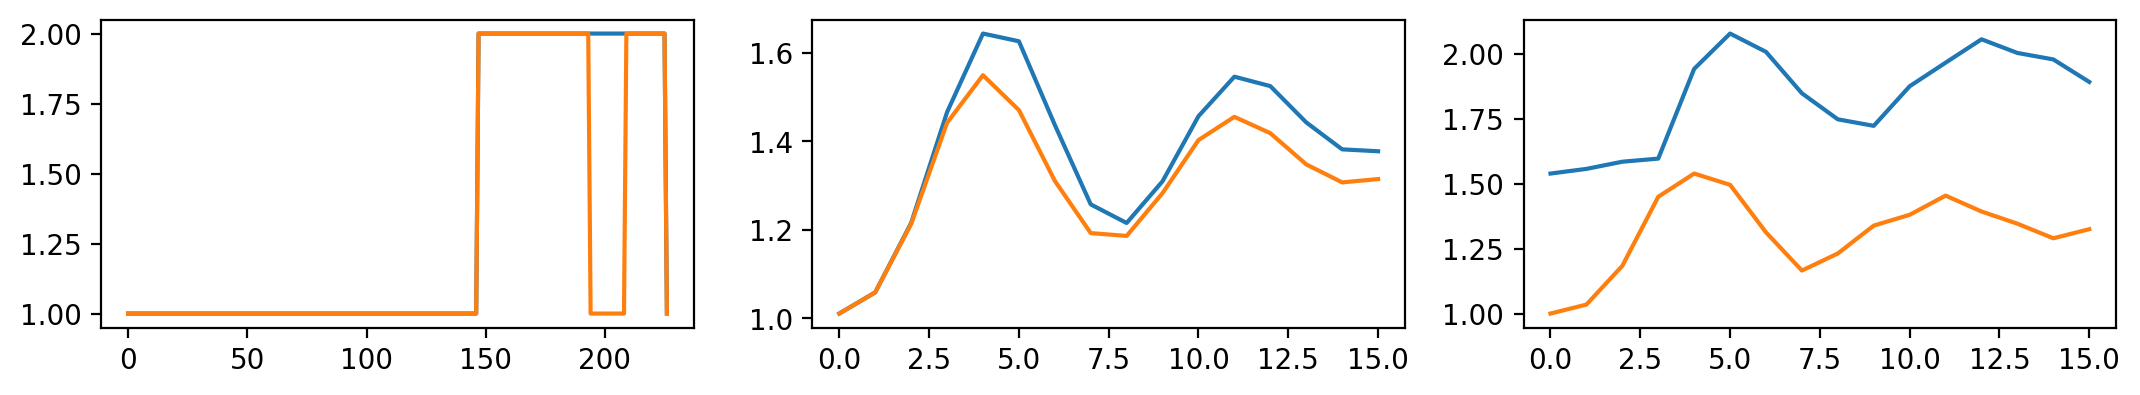

In [695]:
solver.plot_result()